# SOB4ES - Random Forest Multisalida
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook implementa un **Random Forest con salida vectorial**: en lugar de entrenar un modelo independiente por cada variable objetivo, se entrena un unico modelo que predice los 11 targets simultaneamente.

La clave de este enfoque es que cada nodo de cada arbol toma sus decisiones considerando todos los targets a la vez, lo que permite capturar correlaciones entre grupos biologicos. Por ejemplo, si la diversidad de lombrices y la de colémbolos tienden a co-variar, el modelo puede aprender esa relacion.

**Datasets utilizados:**
- `train.csv` - Entrenamiento (70 %, estratificado por pais)
- `test.csv`  - Tuning e hiperparametros (15 %)
- `eval.csv`  - Evaluacion final imparcial (15 %)

**Estructura del notebook:**
1. Configuracion
2. Carga de datos
3. Tuning de hiperparametros
4. Validacion cruzada
5. Importancia de variables
6. Entrenamiento de produccion
7. Evaluacion final

---
## 1. Configuracion del entorno


In [6]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

# Ignorar los warnings
warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/rf_multi/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas.')


Librerias y variables cargadas.


## 2. Carga de datos

Se cargan los tres datasets pre-generados (division 70/15/15, estratificada por pais).

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning / validacion cruzada              | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7.

In [7]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print('Cargando datasets...')
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
X_test  = df_test[FEATURES_AUTORIZADAS]
X_eval  = df_eval[FEATURES_AUTORIZADAS]

# En los modelos multisalida, y es una matriz 2D (n_muestras x n_targets)
# en lugar de un vector 1D. Esto permite al modelo aprender correlaciones entre targets.
y_train = df_train[TARGETS]
y_test  = df_test[TARGETS]
y_eval  = df_eval[TARGETS]

print(f'\nDatasets cargados.')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'X_eval:  {X_eval.shape}   |  y_eval:  {y_eval.shape}')


Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  y_train: (299, 11)
X_test:  (64, 34)   |  y_test:  (64, 11)
X_eval:  (65, 34)   |  y_eval:  (65, 11)


## 3. Busqueda de hiperparametros (Tuning)

La busqueda de hiperparametros es identica a la del Random Forest individual. El modelo acepta `y` como matriz 2D de forma transparente, por lo que el espacio de busqueda no cambia.

La busqueda se realiza sobre `X_train` y `y_train` (todos los targets a la vez).

In [8]:
print('Iniciando busqueda de hiperparametros...')
print('Este proceso puede tardar varios minutos.\n')

param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False]
}

# RandomizedSearchCV no soporta multisalida directamente en el scoring,
# por lo que usamos un unico target de referencia para el tuning
# y luego aplicamos los parametros optimos al modelo multisalida completo.
y_ref = y_train['earthworm_shannon_z'].values

buscador = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=50, scoring='r2', cv=5,
    verbose=1, random_state=42, n_jobs=-1
)

start = time.time()
buscador.fit(X_train, y_ref)

print(f'\nBusqueda completada en {(time.time()-start)/60:.1f} minutos.')
print(f'Mejor R2 de referencia: {buscador.best_score_:.4f}')
print(f'Hiperparametros optimos: {buscador.best_params_}')

RF_MULTI_PARAMS = buscador.best_params_
RF_MULTI_PARAMS['n_jobs'] = -1


Iniciando busqueda de hiperparametros...
Este proceso puede tardar varios minutos.

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aka/Deskto


Busqueda completada en 1.2 minutos.
Mejor R2 de referencia: 0.5056
Hiperparametros optimos: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None, 'bootstrap': True}


## 4. Validacion cruzada

Se evalua la robustez del modelo con validacion cruzada repetida (5 pliegues x 3 repeticiones). Al ser multisalida, el R2 que reporta sklearn es el promedio sobre todos los targets. Se muestra tambien el R2 individual por target para identificar cuales aprende mejor el modelo.

In [9]:
print('Validacion cruzada repetida sobre X_train (todos los targets)...\n')

modelo_cv   = RandomForestRegressor(**RF_MULTI_PARAMS)
cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

resultados = cross_validate(
    estimator=modelo_cv,
    X=X_train, y=y_train,
    cv=cv_splitter,
    scoring='r2',
    return_train_score=True
)

r2_train = np.mean(resultados['train_score'])
r2_cv    = np.mean(resultados['test_score'])
r2_std   = np.std(resultados['test_score'])

print(f'  Train R2 (promedio targets): {r2_train:.4f}')
print(f'  Val   R2 (promedio targets): {r2_cv:.4f} +/- {r2_std:.4f}')

# R2 individual por target (entrenando sobre todo X_train)
modelo_cv.fit(X_train, y_train)
y_pred_train = modelo_cv.predict(X_train)
print('\n  R2 por target (train):')
for i, t in enumerate(TARGETS):
    r2 = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
    print(f'    {t:30} {r2:.4f}')


Validacion cruzada repetida sobre X_train (todos los targets)...

  Train R2 (promedio targets): 0.5175
  Val   R2 (promedio targets): 0.1731 +/- 0.0263

  R2 por target (train):
    nematode_shannon_z             0.5766
    macro_shannon_z                0.6254
    earthworm_shannon_z            0.7222
    orib_shannon_z                 0.5226
    meso_shannon_z                 0.4744
    coll_shannon_z                 0.6035
    bac_shannon_z                  0.4533
    fun_shannon_z                  0.4252
    euk_shannon_z                  0.5265
    oomy_shannon_z                 0.5134
    cerc_shannon_z                 0.4029


## 5. Importancia de variables

Se calcula la importancia de variables mediante permutacion sobre `X_train`. Al ser multisalida, la importancia refleja el impacto de cada variable sobre el conjunto de todos los targets simultaneamente.

Top 10 variables por importancia global (todos los targets):
soil_ph_z                0.1369
gee_temp_media_C_z       0.0976
eu_as_z                  0.0704
gee_humedad_rel_pct_z    0.0527
sand_content_z           0.0425
dem_elevacion_m_z        0.0405
eu_cn_ratio_z            0.0376
eu_p_z                   0.0358
soil_moisture_z          0.0357
eu_ph_z                  0.0257


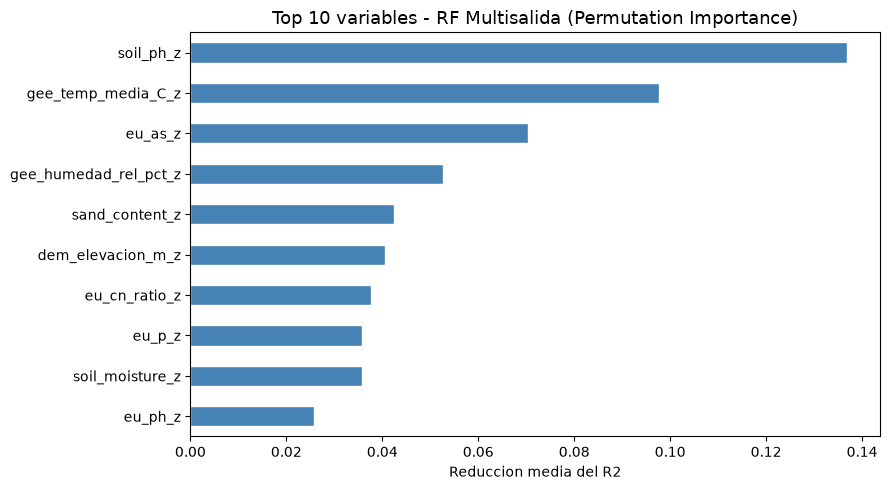

Calculando valores SHAP (RF Multisalida)...


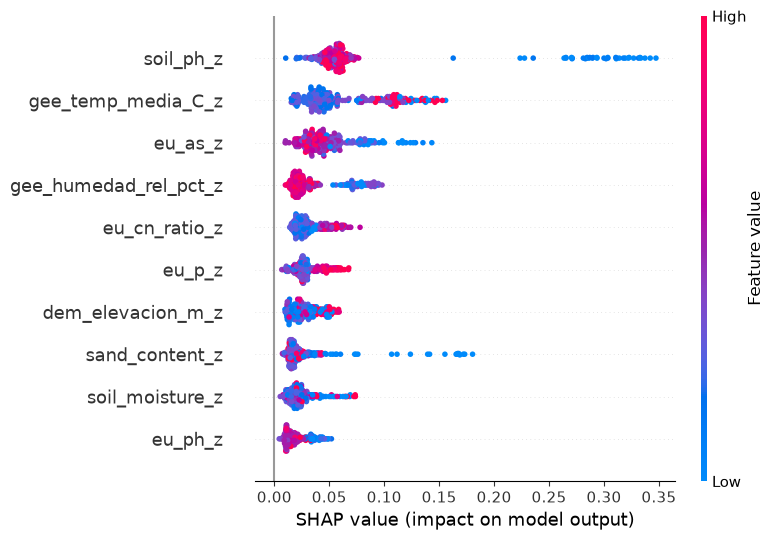

In [10]:
# El modelo ya esta ajustado sobre y_train completo desde la celda anterior
perm = permutation_importance(
    modelo_cv, X_train, y_train,
    n_repeats=10, random_state=42, n_jobs=-1
)

importancias = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)
top10 = importancias.nlargest(10)

print('Top 10 variables por importancia global (todos los targets):')
print(top10.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
importancias.nlargest(10).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 variables - RF Multisalida (Permutation Importance)', fontsize=13)
ax.set_xlabel('Reduccion media del R2')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

import shap

print('Calculando valores SHAP (RF Multisalida)...')
explainer   = shap.TreeExplainer(modelo_cv)
shap_values = explainer.shap_values(X_train)

# Si shap_values es 3D (multisalida), promediamos el valor absoluto sobre todos los targets
if isinstance(shap_values, list):
    shap_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    shap_mean = np.abs(shap_values).mean(axis=2)
else:
    shap_mean = shap_values

shap.summary_plot(shap_mean, X_train, plot_type='dot', max_display=10,
                  show=True)


## 6. Entrenamiento de produccion

Se entrena un ensamble de 5 modelos multisalida, variando la semilla aleatoria. Cada modelo predice los 11 targets a la vez. Promediar el ensamble reduce la varianza de las predicciones finales.

In [11]:
print('Entrenamiento de produccion (ensamble de 5 modelos multisalida)...')
print('-' * 70)

global_start = time.time()
NUM_MODELOS  = 5

for seed_id in range(NUM_MODELOS):
    t0     = time.time()
    params = RF_MULTI_PARAMS.copy()
    params['random_state'] = 42 + seed_id

    # Entrenamos sobre y_train completo (matriz 11 targets)
    model  = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    joblib.dump(model, os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl'))
    print(f'  Modelo {seed_id+1}/5 completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')


Entrenamiento de produccion (ensamble de 5 modelos multisalida)...
----------------------------------------------------------------------
  Modelo 1/5 completado (0.5s)
  Modelo 2/5 completado (0.5s)
  Modelo 3/5 completado (0.4s)
  Modelo 4/5 completado (0.3s)
  Modelo 5/5 completado (0.3s)
----------------------------------------------------------------------
Produccion completada en 0.0 minutos.


## 7. Evaluacion final y prueba de funcionamiento

Esta seccion tiene dos partes:

**Parte A - Evaluacion final**
Se mide por primera vez el rendimiento sobre `eval.csv`, el conjunto de datos que el modelo nunca ha visto. Al ser un modelo multisalida, se calculan las metricas globales (promedio sobre todos los targets) y tambien el R2 individual por target, para identificar cuales predice bien y cuales no.

**Parte B - Prueba de funcionamiento (smoke test)**
Se verificia que el pipeline funciona de extremo a extremo con 3 filas reales de `eval.csv`, comparando la prediccion con el valor real observado para cada target.

---
**Como leer el indice Shannon H':**
Cada target es el indice de diversidad de Shannon de un grupo biologico distinto (lombrices, colémbolos, bacterias, hongos, etc.). El valor va de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad). Un valor tipico en suelos agricolas europeos se situa entre `1.5` y `2.5`.

Evaluacion final sobre eval.csv
------------------------------------------------------------
  R2   global: 0.1076
  RMSE global: 0.9261 puntos de Shannon H'
  MAE  global: 0.7054 puntos de Shannon H'

  R2 por target:
    nematode_shannon_z             0.2176
    macro_shannon_z                0.3178
    earthworm_shannon_z            0.5105
    orib_shannon_z                 0.2203
    meso_shannon_z                 -0.1838
    coll_shannon_z                 -0.1892
    bac_shannon_z                  0.0220
    fun_shannon_z                  -0.0323
    euk_shannon_z                  0.1914
    oomy_shannon_z                 0.1060
    cerc_shannon_z                 0.0033

Smoke test - Inferencia con datos reales
------------------------------------------------------------
  Modelo 1 | Fila 62: 0.1545 | Fila 2: 0.2514 | Fila 54: -0.8987  (earthworm_shannon_z)
  Modelo 2 | Fila 62: 0.1932 | Fila 2: 0.1930 | Fila 54: -0.5789  (earthworm_shannon_z)
  Modelo 3 | Fila 62: 0.1749 | Fila 2

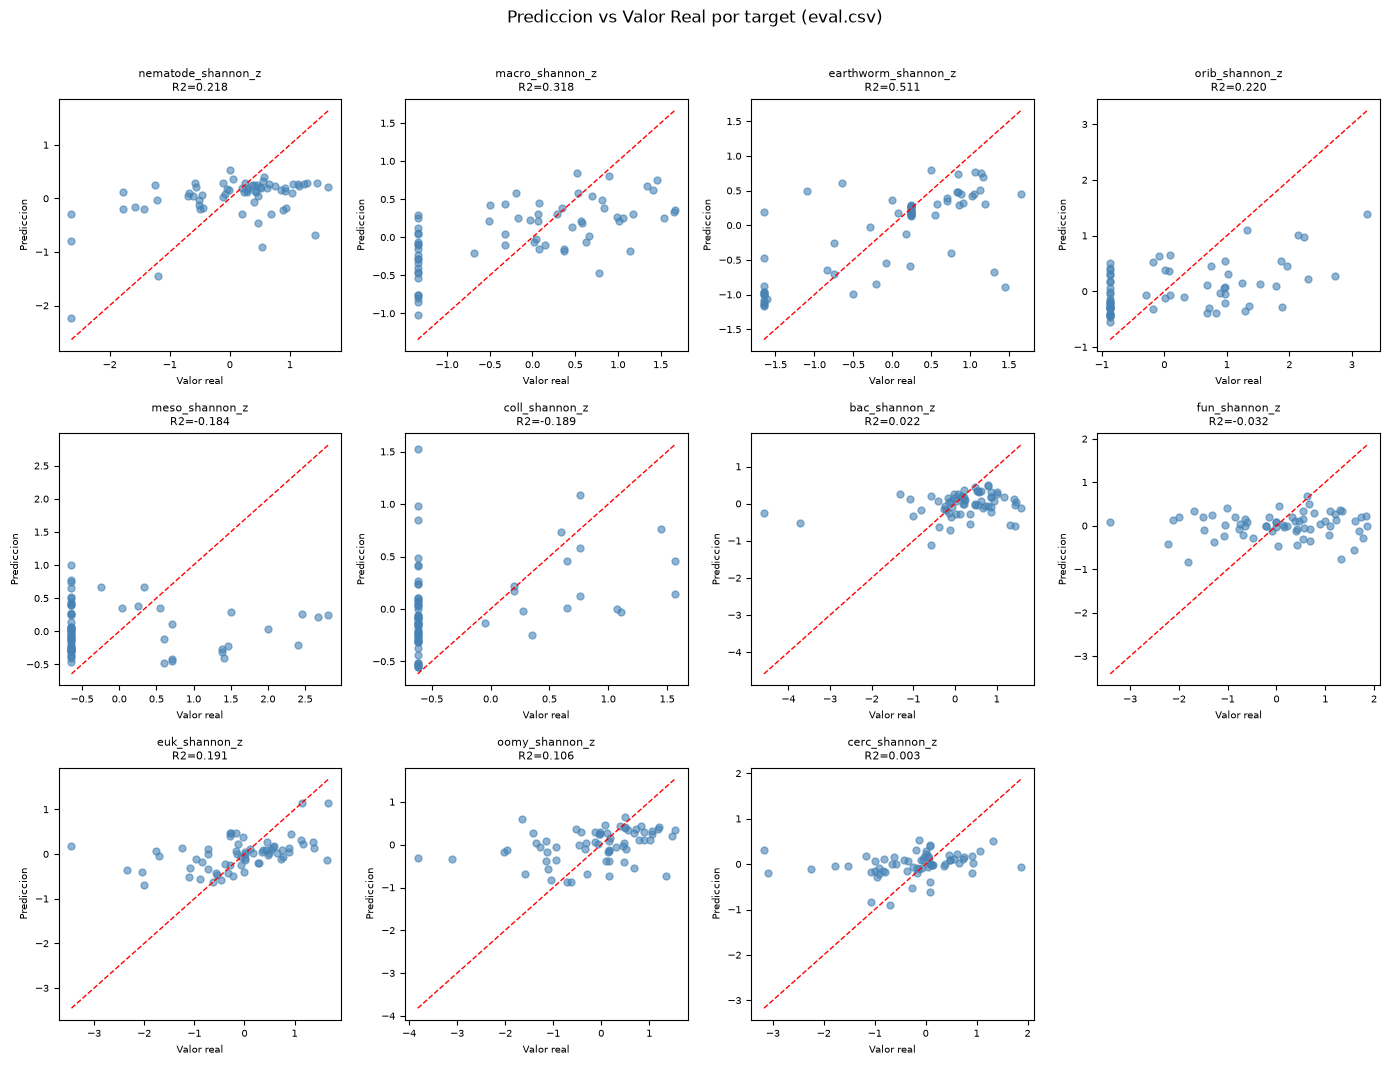

In [12]:
NUM_MODELOS = 5

# ─────────────────────────────────────────────────────────────────────────
# PARTE A: Evaluacion final
# Cargamos los 5 modelos y promediamos sus predicciones sobre eval.csv.
# ─────────────────────────────────────────────────────────────────────────
print('Evaluacion final sobre eval.csv')
print('-' * 60)

preds_eval = []
for seed_id in range(NUM_MODELOS):
    ruta  = os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl')
    model = joblib.load(ruta)
    preds_eval.append(model.predict(X_eval))

# y_pred_eval es una matriz (n_muestras x 11 targets)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

# Metricas globales (promedio sobre todos los targets)
r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} puntos de Shannon H\'')
print(f'  MAE  global: {mae_global:.4f} puntos de Shannon H\'')

# R2 individual por target
print('\n  R2 por target:')
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for t, r2 in zip(TARGETS, r2_por_target):
    print(f'    {t:30} {r2:.4f}')

# ─────────────────────────────────────────────────────────────────────────
# PARTE B: Smoke test con datos reales
# ─────────────────────────────────────────────────────────────────────────
print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3)
    indices_elegidos = df_new_data.index
    valores_reales   = y_eval.loc[indices_elegidos].values

    votos = []
    for seed_id in range(NUM_MODELOS):
        ruta  = os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl')
        m     = joblib.load(ruta)
        pred  = m.predict(df_new_data)
        votos.append(pred)
        # pred es una matriz (3 muestras x 11 targets)
        print(f'  Modelo {seed_id+1} | '
              f'Fila {indices_elegidos[0]}: {pred[0, 0]:.4f} | '
              f'Fila {indices_elegidos[1]}: {pred[1, 0]:.4f} | '
              f'Fila {indices_elegidos[2]}: {pred[2, 0]:.4f}  (earthworm_shannon_z)')

    consenso = np.mean(votos, axis=0)
    print('-' * 60)
    print('  Resultados detallados por muestra (earthworm_shannon_z):')
    print('-' * 60)

    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, TARGETS.index('earthworm_shannon_z')]
        real_val = y_eval.loc[idx, 'earthworm_shannon_z']
        error    = abs(pred_val - real_val)
        print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
              f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('-' * 60)
    print('\nSmoke test superado. El pipeline multisalida funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: prediccion vs valor real por target
# Scatter: prediccion vs valor real para cada target sobre eval.csv
n_targets = len(TARGETS)
n_cols    = 4
n_rows    = (n_targets + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, t in enumerate(TARGETS):
    ax = axes[i]
    ax.scatter(y_true_eval[:, i], y_pred_eval[:, i], alpha=0.6, s=25, color='steelblue')
    # Linea de prediccion perfecta
    lim = [min(y_true_eval[:, i].min(), y_pred_eval[:, i].min()),
           max(y_true_eval[:, i].max(), y_pred_eval[:, i].max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Prediccion perfecta')
    r2 = r2_score(y_true_eval[:, i], y_pred_eval[:, i])
    ax.set_title(f'{t}\nR2={r2:.3f}', fontsize=8)
    ax.set_xlabel('Valor real', fontsize=7)
    ax.set_ylabel('Prediccion', fontsize=7)
    ax.tick_params(labelsize=7)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Prediccion vs Valor Real por target (eval.csv)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
